In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm

c:\Users\Aya\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(r"C:\Users\Aya\Desktop\Data Mining Project (2)\Data Mining Project\balanced_sentiment_dataset_1000.csv.xls")

df.head()

,id,text,label
0,1,Everything works better than expected variatio...,positive
1,2,High quality and excellent experience variatio...,positive
2,3,Very slow and annoying experience variation 27,negative
3,4,Waste of money and time variation 89,negative
4,5,This is an amazing experience variation 122,positive


In [3]:
if list(df.columns[:3]) == ['A', 'B', 'C']:
    df.columns = ['id', 'text', 'label']

df = df.dropna(subset=['text', 'label'])
df = df.reset_index(drop=True)

In [4]:
print("\nOriginal label distribution:")
print(df['label'].value_counts())

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"  

sentiment_pipeline = pipeline("sentiment-analysis", model=model_name, device=-1) 


Original label distribution:
label
positive    334
negative    333
normal      333
Name: count, dtype: int64


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1610.23it/s]


In [5]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

def convert_label(label):
    """
    CARDIFF NLP OUTPUT:
    LABEL_0 -> negative
    LABEL_1 -> neutral
    LABEL_2 -> positive
    """
    if label == "LABEL_0":
        return "negative"
    elif label == "LABEL_1":
        return "normal"
    else:
        return "positive"

df_subset = df.copy()   

predictions = []

print("🚀 Running BERT Sentiment Analysis...")

for text in tqdm(df_subset['text']):
    try:
        result = sentiment_pipeline(str(text)[:512])[0]

        sentiment = convert_label(result['label'])
        predictions.append(sentiment)

    except:
        predictions.append("normal")  

df_subset['bert_label'] = predictions




Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15136.45it/s]


🚀 Running BERT Sentiment Analysis...


100%|██████████| 1000/1000 [00:41<00:00, 23.95it/s]


In [6]:
print("\n📊 Classification Report:\n")

print(
    classification_report(
        df_subset['label'],       
        df_subset['bert_label'],   
        labels=['positive', 'negative', 'normal']
    )
)


📊 Classification Report:

              precision    recall  f1-score   support

    positive       0.91      1.00      0.95       334
    negative       1.00      1.00      1.00       333
      normal       1.00      0.89      0.94       333

    accuracy                           0.96      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.97      0.96      0.96      1000



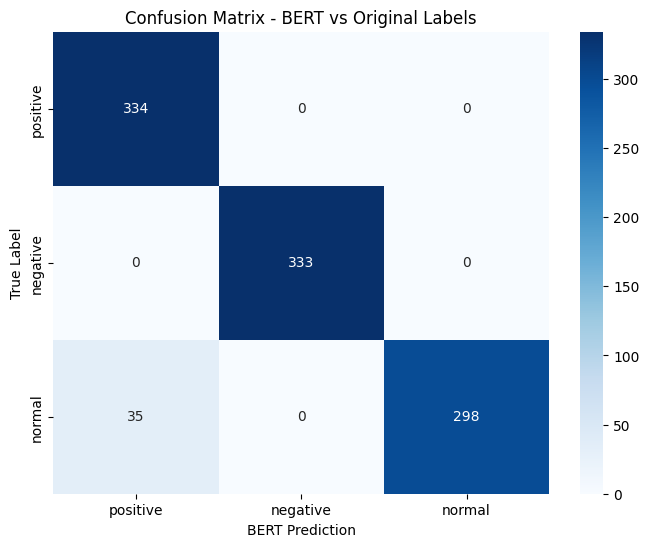

In [7]:
cm = confusion_matrix(df_subset['label'], df_subset['bert_label'], labels=['positive', 'negative', 'normal'])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'negative', 'normal'], yticklabels=['positive', 'negative', 'normal'])
plt.xlabel("BERT Prediction")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BERT vs Original Labels")
plt.show()

In [8]:
df_subset['match'] = df_subset['label'] == df_subset['bert_label']
disagreements = df_subset[~df_subset['match']]
print(f"\nNumber of cases where BERT disagreed with the original label: {len(disagreements)}")
print("\nExamples of disagreements:")
print(disagreements[['text', 'label', 'bert_label']].head(10))


Number of cases where BERT disagreed with the original label: 35

Examples of disagreements:
                                              text   label bert_label
63            The sky is clear today variation 191  normal   positive
131           The sky is clear today variation 331  normal   positive
184           The sky is clear today variation 141  normal   positive
225            The sky is clear today variation 81  normal   positive
234           The sky is clear today variation 241  normal   positive
307           The sky is clear today variation 121  normal   positive
313  We visited the museum last week variation 100  normal   positive
336           The sky is clear today variation 231  normal   positive
346           The sky is clear today variation 321  normal   positive
348            The sky is clear today variation 91  normal   positive


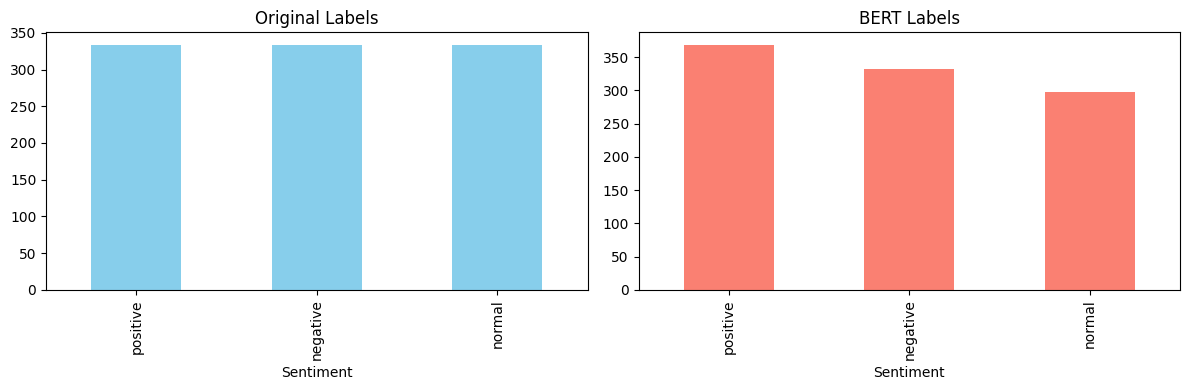

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df_subset['label'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', title='Original Labels')
df_subset['bert_label'].value_counts().plot(kind='bar', ax=axes[1], color='salmon', title='BERT Labels')
axes[0].set_xlabel("Sentiment")
axes[1].set_xlabel("Sentiment")
plt.tight_layout()
plt.show()

In [10]:
print("\nBERT accuracy for each class:")
for sentiment in ['positive', 'negative', 'normal']:
    subset = df_subset[df_subset['label'] == sentiment]
    accuracy = (subset['label'] == subset['bert_label']).mean()
    print(f"{sentiment}: {accuracy:.2f} ({len(subset)} samples)")


BERT accuracy for each class:
positive: 1.00 (334 samples)
negative: 1.00 (333 samples)
normal: 0.89 (333 samples)


In [11]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", 
                     model="nlptown/bert-base-multilingual-uncased-sentiment")

def test(text):
    result = classifier(text[:512])[0]
    rating = int(result['label'].split()[0])
    if rating <= 2:
        sentiment = "negative"
    elif rating == 3:
        sentiment = "neutral"
    else:
        sentiment = "positive"
    print(f"'{text}' → {sentiment} ({rating}/5, confidence: {result['score']:.2%})")

test("I love this product!")
test("This is terrible.")
test("The sky is blue.")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3712.02it/s]


'I love this product!' → positive (5/5, confidence: 91.35%)
'This is terrible.' → negative (1/5, confidence: 93.10%)
'The sky is blue.' → neutral (3/5, confidence: 28.78%)
